In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [40]:
df = pd.read_csv("Sample - Superstore.csv",encoding = 'latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [41]:
print("Shape of dataset:",df.shape)
print("Column Names:\n",df.columns.tolist())

Shape of dataset: (9994, 21)
Column Names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [42]:
print("Missing Values:\n",df.isnull().sum())
print("\nData Types:\n",df.dtypes)

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data Types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [43]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [44]:
print("Date coulmns fixed!")
print(df[['Order Date', 'Ship Date']].dtypes)

Date coulmns fixed!
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [45]:
print("Total Sales:", round(df['Sales'].sum(),2))
print("Total Profit:", round(df['Profit'].sum(),2))
print("Total Orders:", df['Order ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793


In [46]:
region_sales = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
print(region_sales)

             Sales     Profit
Region                       
Central  501239.89   39706.36
East     678781.24   91522.78
South    391721.90   46749.43
West     725457.82  108418.45


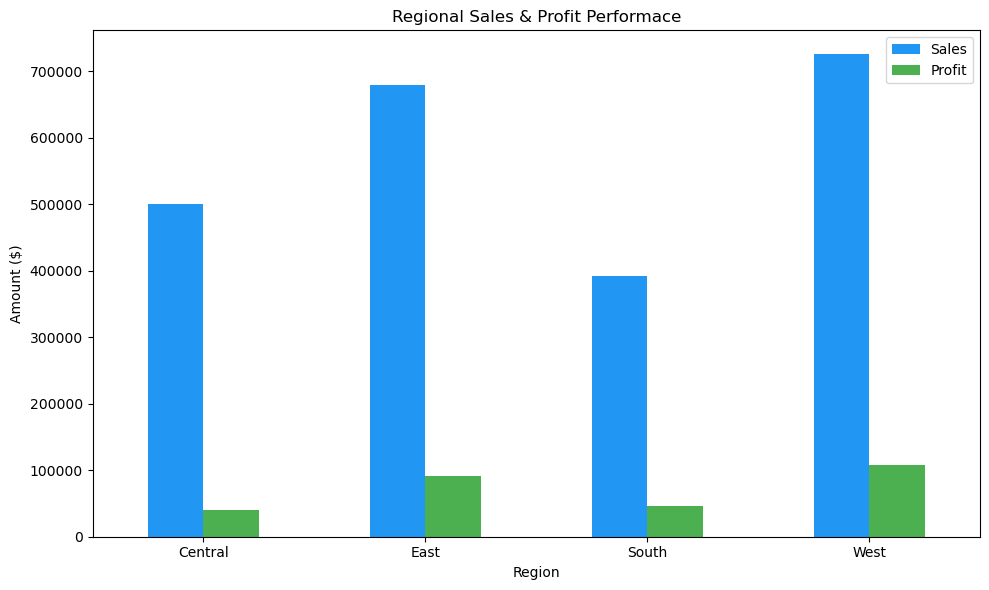

In [47]:
region_sales.plot(kind='bar', figsize=(10,6), color=['#2196F3','#4CAF50'])
plt.title('Regional Sales & Profit Performace')
plt.xlabel('Region')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
#Central region shows low profit margin of 7.9% compared to West's 14.9% — possible causes include 
#high discounts or operational costs — requires further investigation!

In [49]:
category_sales = df.groupby('Category')[['Sales','Profit']].sum().round(2)
print(category_sales)

                     Sales     Profit
Category                             
Furniture        741999.80   18451.27
Office Supplies  719047.03  122490.80
Technology       836154.03  145454.95


In [50]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

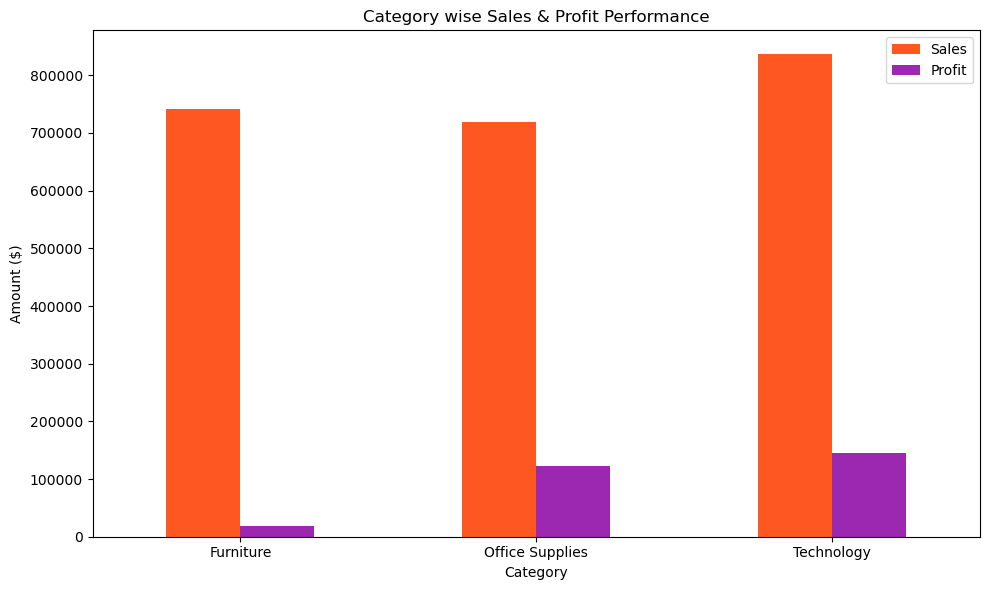

In [51]:
category_sales.plot(kind='bar',figsize=(10,6), color=['#FF5722','#9C27B0','#2196F3'])
plt.title('Category wise Sales & Profit Performance')
plt.xlabel('Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [53]:
Top_10_products=df.groupby('Product Name')[['Sales']].sum().round(2).nlargest(10,'Sales')
print(Top_10_products)

                                                       Sales
Product Name                                                
Canon imageCLASS 2200 Advanced Copier               61599.82
Fellowes PB500 Electric Punch Plastic Comb Bind...  27453.38
Cisco TelePresence System EX90 Videoconferencin...  22638.48
HON 5400 Series Task Chairs for Big and Tall        21870.58
GBC DocuBind TL300 Electric Binding System          19823.48
GBC Ibimaster 500 Manual ProClick Binding System    19024.50
Hewlett Packard LaserJet 3310 Copier                18839.69
HP Designjet T520 Inkjet Large Format Printer -...  18374.90
GBC DocuBind P400 Electric Binding System           17965.07
High Speed Automatic Electric Letter Opener         17030.31


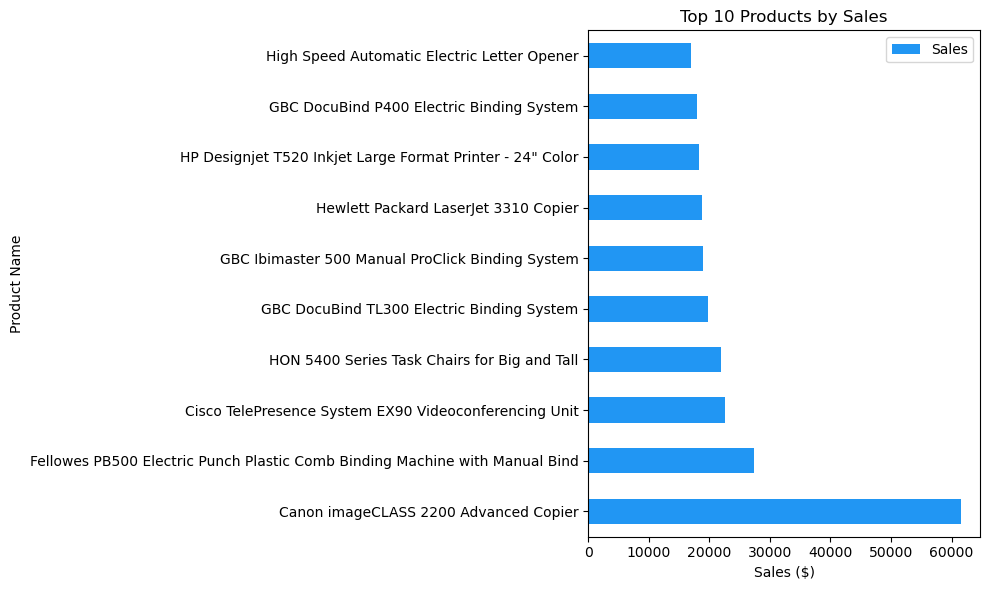

In [54]:
Top_10_products.plot(kind='barh', figsize=(10,6), color='#2196F3')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

In [55]:
df['Year'] = df['Order Date'].dt.year
df['Month'] =  df['Order Date'].dt.month
print(df[['Order Date', 'Year', 'Month']].head())

  Order Date  Year  Month
0 2016-11-08  2016     11
1 2016-11-08  2016     11
2 2016-06-12  2016      6
3 2015-10-11  2015     10
4 2015-10-11  2015     10


In [56]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Year',
 'Month']

In [57]:
print(df.shape)

(9994, 23)


In [59]:
yearly_sales = df.groupby('Year')['Sales'].sum().round(2)
print(yearly_sales)

Year
2014    484247.50
2015    470532.51
2016    609205.60
2017    733215.26
Name: Sales, dtype: float64


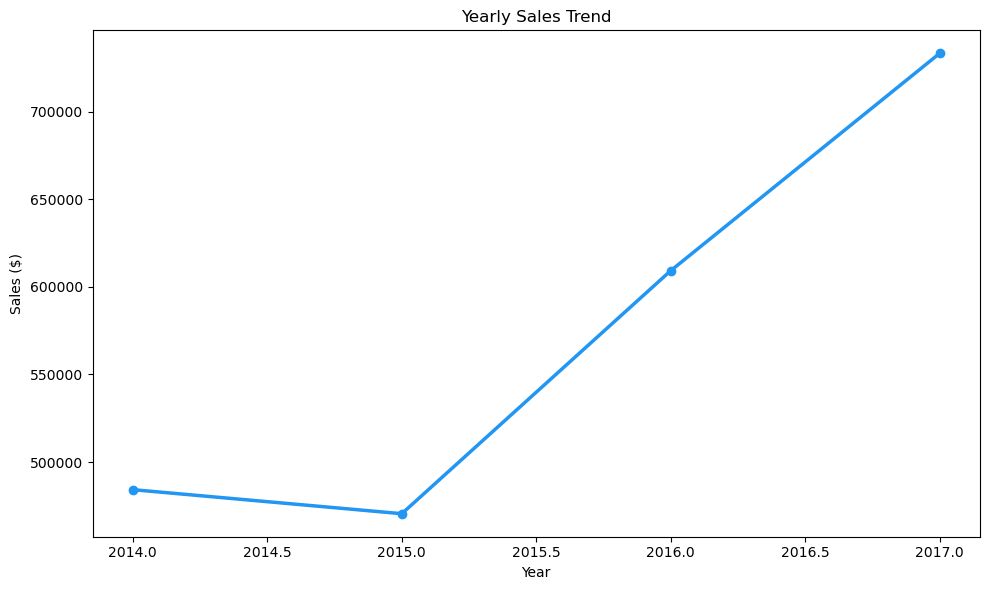

In [61]:
yearly_sales.plot(kind='line', figsize=(10,6), color='#2196F3', marker='o', linewidth=2.5)
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'Business Sales Performance Dashboard')

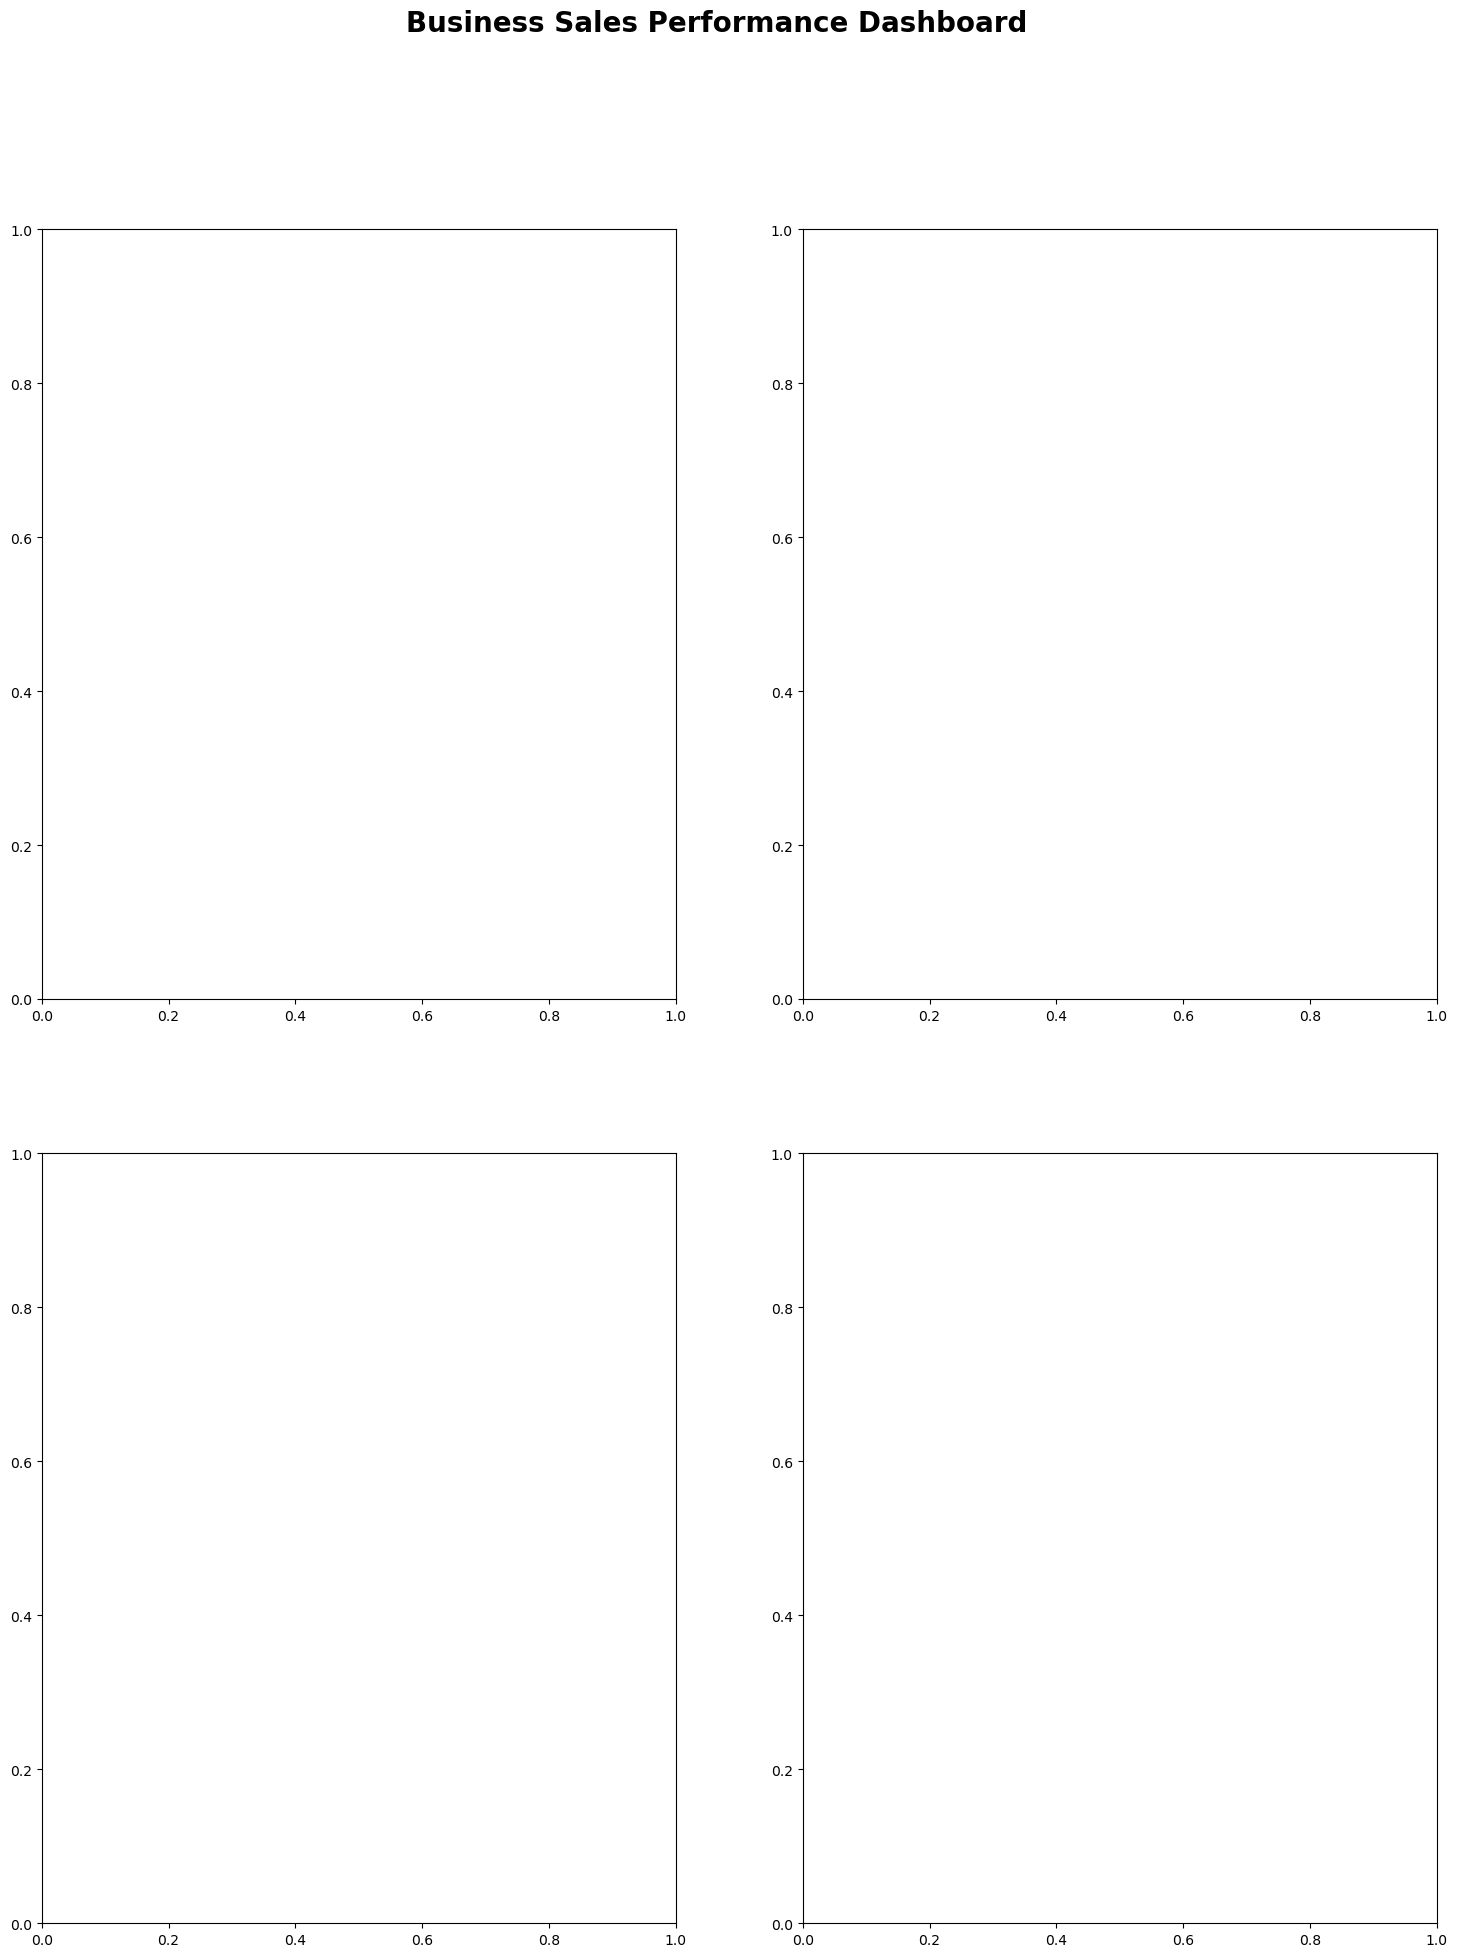

In [63]:
fig, axes = plt.subplots(2,2, figsize = (18,22))
fig.suptitle('Business Sales Performance Dashboard',
            fontsize=20, fontweight='bold')

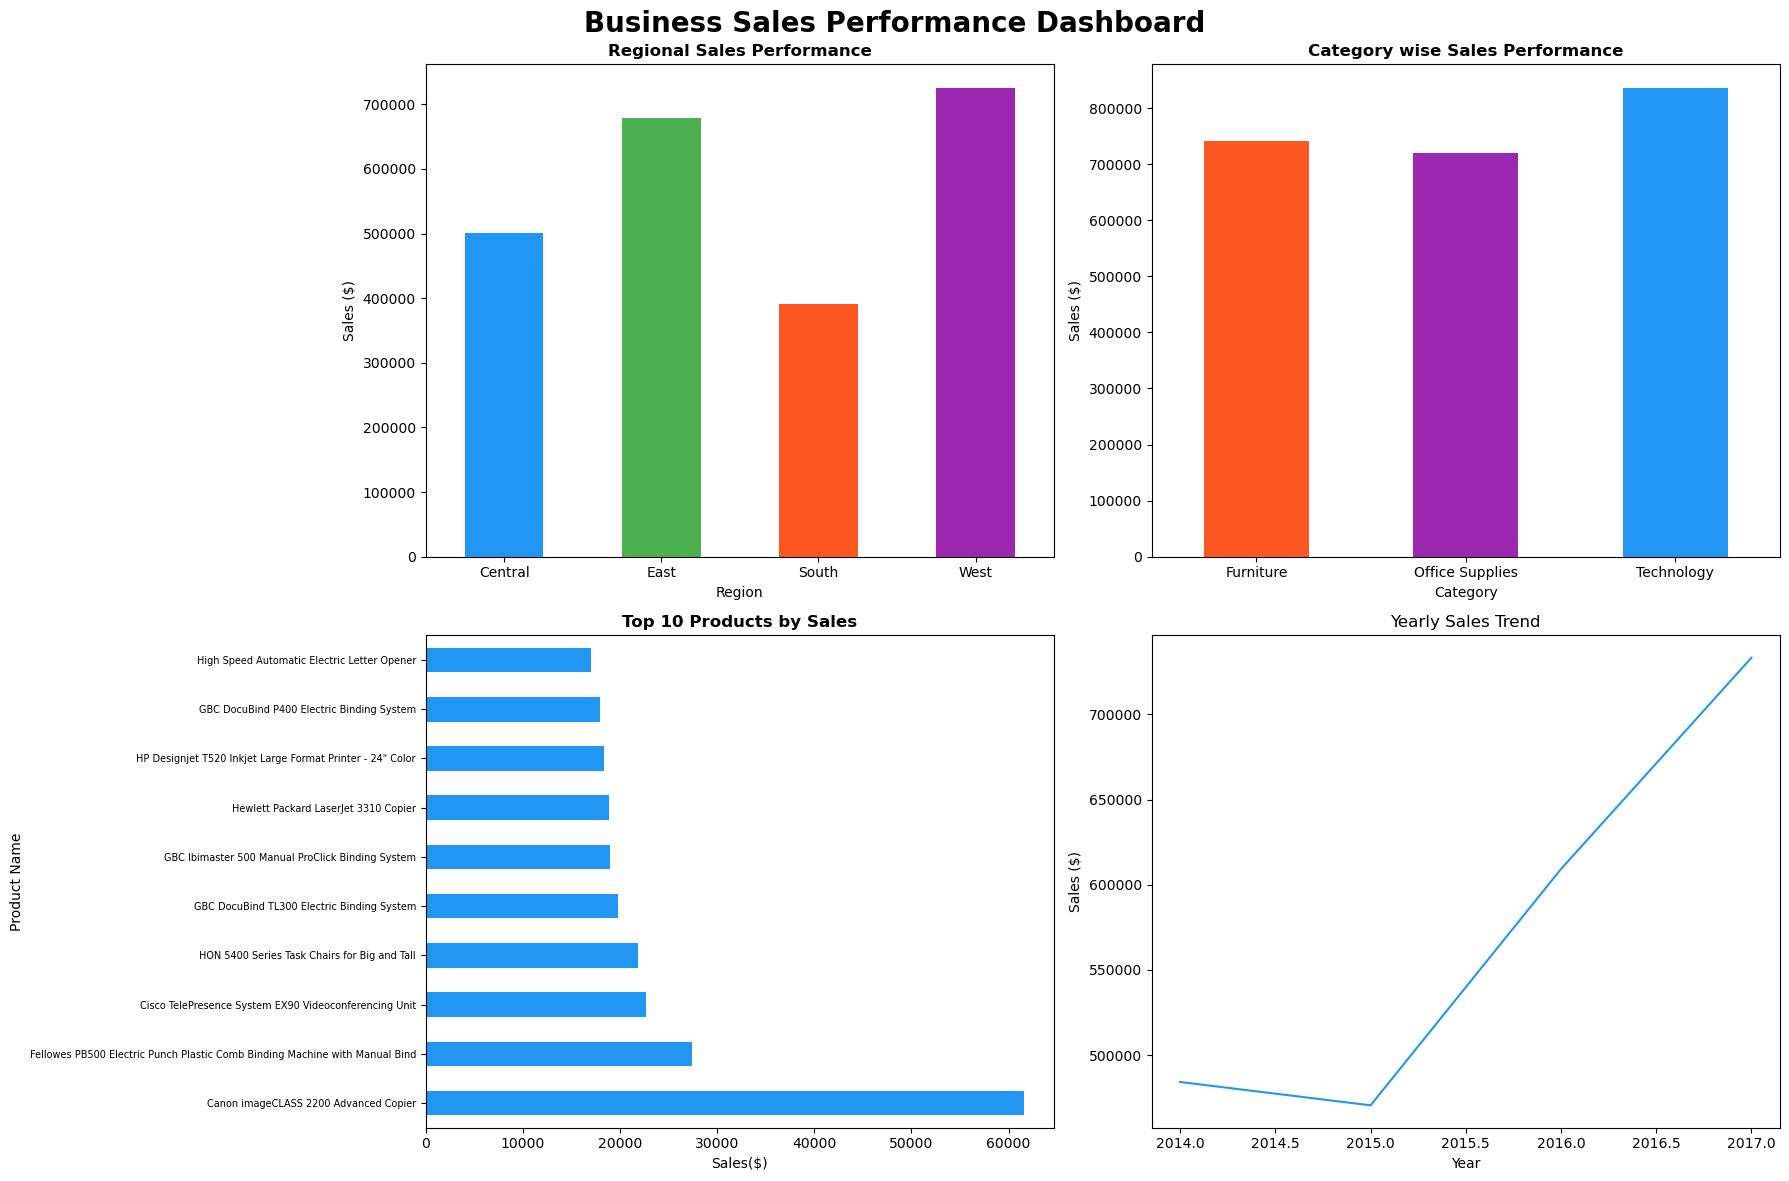

In [86]:
plt.close('all')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Business Sales Performance Dashboard', 
             fontsize=20, fontweight='bold')

#Chart 1 - Regional Sales
region_sales['Sales'].plot(kind='bar', ax=axes[0,0],
                            color=['#2196F3','#4CAF50','#FF5722','#9C27B0'])
axes[0,0].set_title('Regional Sales Performance', fontweight='bold')
axes[0,0].set_xlabel('Region')
axes[0,0].set_ylabel('Sales ($)')
axes[0,0].tick_params(axis='x', rotation=0)

#Chart 2 - Category Sales
category_sales['Sales'].plot(kind='bar', ax=axes[0,1],
                            color=['#FF5722','#9C27B0','#2196F3'])
axes[0,1].set_title('Category wise Sales Performance', fontweight='bold')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Sales ($)')
axes[0,1].tick_params(axis='x', rotation=0)


#Chart 3 - Top  10 products
Top_10_products['Sales'].plot(kind='barh', ax=axes[1,0],
                             color='#2196F3')
axes[1,0].set_title('Top 10 Products by Sales', fontweight='bold')
axes[1,0].set_xlabel('Sales($)')
axes[1,0].set_ylabel('Product Name')
axes[1,0].tick_params(axis='y', labelsize=7)

#Chart 4 - Yearly Sales Trend
yearly_sales.plot(kind='line', ax=axes[1,1],
                 color='#2196F3')
axes[1,1].set_title('Yearly Sales Trend')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Sales ($)')

plt.tight_layout()
plt.savefig('Sales_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

##  Key Insights & Recommendations

###  Overall Business Performance
- Total Revenue: 2,297,200 USD with a profit margin of approximately 12.5%
- 793 unique customers generated 5,009 orders — averaging 6 orders per customer indicating strong customer loyalty!

###  Regional Performance
- Looking at the regional data, West region clearly stands out with highest sales and profit — making it the most valuable region for this business!
- **West region** is the top performer with 725,457 USD in sales and 14.9% profit margin
- **Central region** shows a red flag — 501,239 USD in sales but only 7.9% profit margin
- Possible causes for Central's low margin: high discounts or operational costs — requires further investigation!

###  Category Performance
- **Technology** is the most profitable category with 17.4% profit margin
- **Furniture** is critically underperforming with only 2.4% profit margin despite 741,999 USD in sales
- Recommendation: Review discount strategy and shipping costs for Furniture category!

###  Top Products
- **Canon imageCLASS 2200** is the star product with 61,599 USD in sales — nearly double the second best product!
- Recommendation: Increase stock in West and East regions!

###  Sales Trend
- Business shows consistent upward trend from 2014 to 2017
- Strong 20% YoY growth in 2017 indicating healthy business momentum!

###  Final Recommendation
- Focus investment in West and East regions
- Urgently review Furniture category profitability
- Expand Technology product range as it drives highest margins! 